# Análise de Receita e Segmentação ABC de Clientes

## Contexto
Este projeto tem como objetivo analisar a concentração de receita e classificar clientes utilizando a metodologia ABC (Curva de Pareto), com foco em priorização estratégica comercial.

## Perguntas de Negócio
- Existe concentração de receita em poucos clientes?
- Quem são os clientes mais relevantes?
- Como segmentar a base para tomada de decisão?

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("sales.csv", encoding="latin1")
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [3]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [4]:
receita_total = df["SALES"].sum()
total_clientes = df["CUSTOMERNAME"].nunique()

print(f"Receita Total: R${receita_total:.2f}")
print(f"Total de Clientes: {total_clientes}")


Receita Total: R$10032628.85
Total de Clientes: 92


In [5]:
receita_cliente = (df.groupby("CUSTOMERNAME")["SALES"].sum().reset_index())

receita_cliente = receita_cliente.sort_values(by="SALES", ascending=False)

In [6]:
receita_cliente["perc_receita"] = receita_cliente["SALES"] / receita_total
receita_cliente["perc_acumulado"] = receita_cliente["perc_receita"].cumsum()

In [7]:
# Segmentação ABC

def classificar(x):
    if x <= 0.5:
        return "A - Alto Valor"
    elif x <= 0.8:
        return "B - Médio Valor"
    else:
        return "C - Baixo Valor"
    
receita_cliente["segmento"] = receita_cliente["perc_acumulado"].apply(classificar)

receita_cliente["segmento"].value_counts()

resumo_qtd = receita_cliente["segmento"].value_counts().reset_index()
resumo_qtd.columns = ["segmento", "quantidade_clientes"]
resumo_qtd

,segmento,quantidade_clientes
0,C - Baixo Valor,36
1,B - Médio Valor,31
2,A - Alto Valor,25


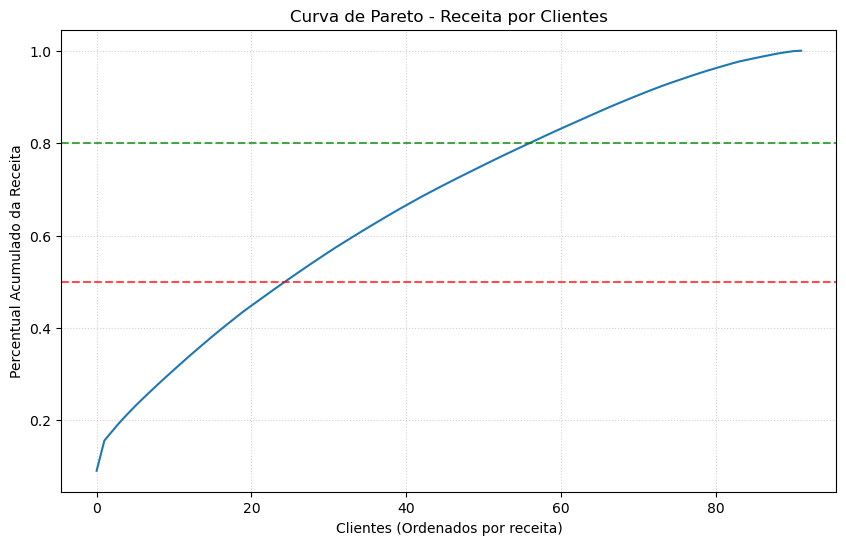

In [8]:
# Curva de Pareto

plt.figure(figsize=(10,6))

plt.plot(receita_cliente["perc_acumulado"].reset_index(drop=True))
plt.axhline(0.5, linestyle= "--", color= "red", alpha= 0.7, label= 'Limite 50% (Classe A)')
plt.axhline(0.8, linestyle= "--", color= "green", alpha= 0.7, label= 'Limite 80% (Classe B)')
plt.title("Curva de Pareto - Receita por Clientes")
plt.xlabel("Clientes (Ordenados por receita)")
plt.ylabel("Percentual Acumulado da Receita")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

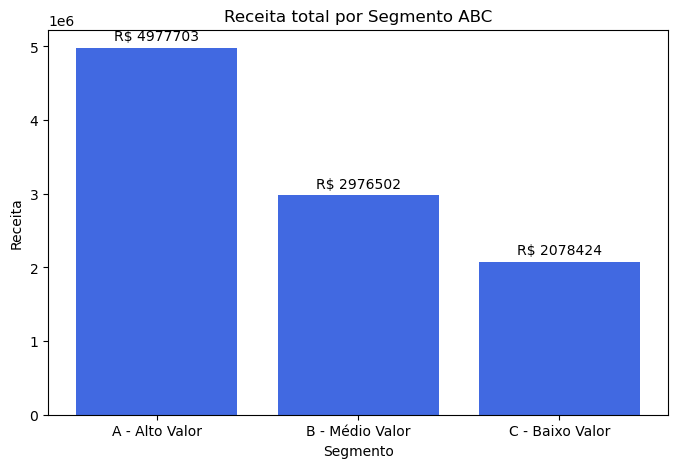

In [9]:
# Receita por segmento

resumo_segmento = (receita_cliente.groupby("segmento")["SALES"].sum().reset_index())

plt.figure(figsize=(8,5))
barras = plt.bar(resumo_segmento["segmento"], resumo_segmento["SALES"], color='royalblue')

plt.bar_label(barras, padding=3, fmt='R$ %.0f')
plt.title("Receita total por Segmento ABC")
plt.xlabel("Segmento")
plt.ylabel("Receita")
plt.show()


## Conclusões

- A receita total analisada foi de R$ R$10.032.628,85.
- Observa-se concentração significativa: aproximadamente 50% da receita está concentrada na classe A.
- A classe B complementa até 80% da receita total.
- A empresa apresenta dependência estratégica de clientes da classe A.
- Recomenda-se:
    - Estratégia de retenção para clientes A.
    - Estratégia de expansão para clientes B.
    - Estratégia de ativação ou automação para clientes C.

# Análise Comercial Estratégica

In [10]:
# Receita por territorio

receita_territorio = (df.groupby("TERRITORY")["SALES"].sum().reset_index().sort_values(by="SALES", ascending=False))

receita_territorio["perc_particioacao"] = (receita_territorio["SALES"] / receita_total)

receita_territorio

,TERRITORY,SALES,perc_particioacao
1,EMEA,4979272.41,0.496308
0,APAC,746121.83,0.074370
2,Japan,455173.22,0.045369


In [11]:
# Tiket Médio por Cliente

pedidos_clientes = (df.groupby("CUSTOMERNAME")["ORDERNUMBER"].nunique().reset_index())

receita_cliente_v2 = (df.groupby("CUSTOMERNAME")["SALES"].sum().reset_index())

ticket_cliente = receita_cliente_v2.merge(pedidos_clientes, on="CUSTOMERNAME")

ticket_cliente["ticket_medio"] = (ticket_cliente["SALES"] / ticket_cliente["ORDERNUMBER"])

ticket_cliente.sort_values(by="ticket_medio", ascending=False).head()

,CUSTOMERNAME,SALES,ORDERNUMBER,ticket_medio
87,"Vida Sport, Ltd",117713.56,2,58856.780000
0,"AV Stores, Co.",157807.81,3,52602.603333
48,Marta's Replicas Co.,103080.38,2,51540.190000
39,Heintze Collectables,100595.55,2,50297.775000
83,"Toms Spezialitten, Ltd",100306.58,2,50153.290000


In [12]:
# Receita por linha de produto

receita_produto = (df.groupby("PRODUCTLINE")["SALES"].sum().reset_index().sort_values(by="SALES", ascending=False))

receita_produto


,PRODUCTLINE,SALES
0,Classic Cars,3919615.66
6,Vintage Cars,1903150.84
1,Motorcycles,1166388.34
5,Trucks and Buses,1127789.84
2,Planes,975003.57
3,Ships,714437.13
4,Trains,226243.47


In [13]:
# Receita por ano

receita_ano = (df.groupby("YEAR_ID")["SALES"].sum().reset_index().sort_values("YEAR_ID"))


receita_ano

,YEAR_ID,SALES
0,2003,3516979.54
1,2004,4724162.60
2,2005,1791486.71


In [14]:
# Cruzamento ABC

abc_territorio = df.merge(receita_cliente[["CUSTOMERNAME", "segmento"]], on= "CUSTOMERNAME")

abc_territorio_resumo = (abc_territorio.groupby(["TERRITORY", "segmento"])["SALES"].sum().reset_index())

abc_territorio_resumo

,TERRITORY,segmento,SALES
0,APAC,A - Alto Valor,506562.52
1,APAC,B - Médio Valor,115498.73
2,APAC,C - Baixo Valor,124060.58
3,EMEA,A - Alto Valor,2476424.17
4,EMEA,B - Médio Valor,1494567.47
5,EMEA,C - Baixo Valor,1008280.77
6,Japan,A - Alto Valor,293552.42
7,Japan,B - Médio Valor,94015.73
8,Japan,C - Baixo Valor,67605.07


In [15]:
# Meses por ano

df.groupby("YEAR_ID")["MONTH_ID"].nunique()

YEAR_ID
2003    12
2004    12
2005     5
Name: MONTH_ID, dtype: int64

### Análise Temporal

- 2004 apresentou o maior volume de receita anual.
- O ano de 2005 contém apenas 5 meses registrados, não sendo comparável integralmente aos anos anteriores.

# Conclusão Geral – Análise Comercial Estratégica

**1️- Estrutura de Receita**

A análise evidencia forte concentração geográfica da receita na região EMEA, responsável por aproximadamente 49% do faturamento total.

Essa concentração indica dependência relevante de um único território, o que pode representar risco estratégico em cenários de instabilidade econômica ou redução de demanda regional.

As regiões APAC e Japan apresentam participação significativamente inferior no faturamento total.

**2- Estrutura de Portfólio**

O faturamento está majoritariamente concentrado nas linhas Classic Cars e Vintage Cars, caracterizando dependência de um nicho específico de mercado.

Embora esses produtos apresentem forte desempenho, a concentração pode representar vulnerabilidade caso ocorra redução na demanda por esse segmento.

**3- Análise Temporal**

O ano de 2004 apresentou o maior volume de receita no período analisado.

O ano de 2005 contém apenas cinco meses registrados no dataset, não sendo comparável integralmente aos anos anteriores. Portanto, não é possível concluir tendência anual completa para esse período.

**4- Insights Estratégicos**

Priorizar retenção e relacionamento com clientes do segmento A, responsáveis pela maior parcela da receita.

Desenvolver estratégias para aumentar o ticket médio e o volume de compras dos clientes B e C.

Avaliar oportunidades de expansão geográfica para reduzir dependência de EMEA.

Monitorar diversificação do portfólio para mitigar risco de concentração por linha de produto.

# Análise Grafica

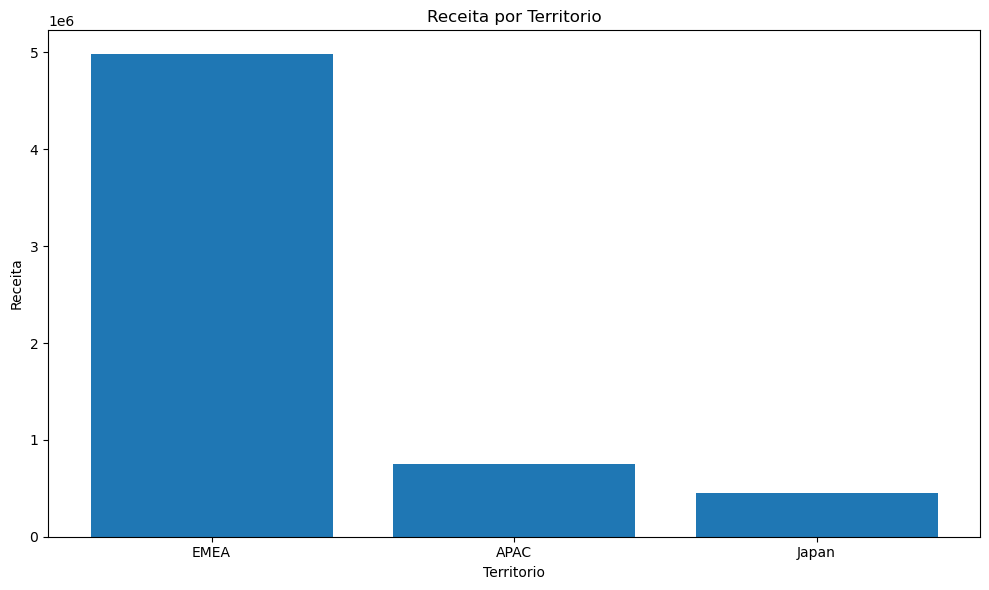

In [16]:
# Grafico de barras - Receita por territorio

plt.figure(figsize=(10,6))
plt.bar(receita_territorio["TERRITORY"], receita_territorio["SALES"])
plt.xlabel("Territorio")
plt.ylabel("Receita")
plt.title("Receita por Territorio")
plt.tight_layout()
plt.show()

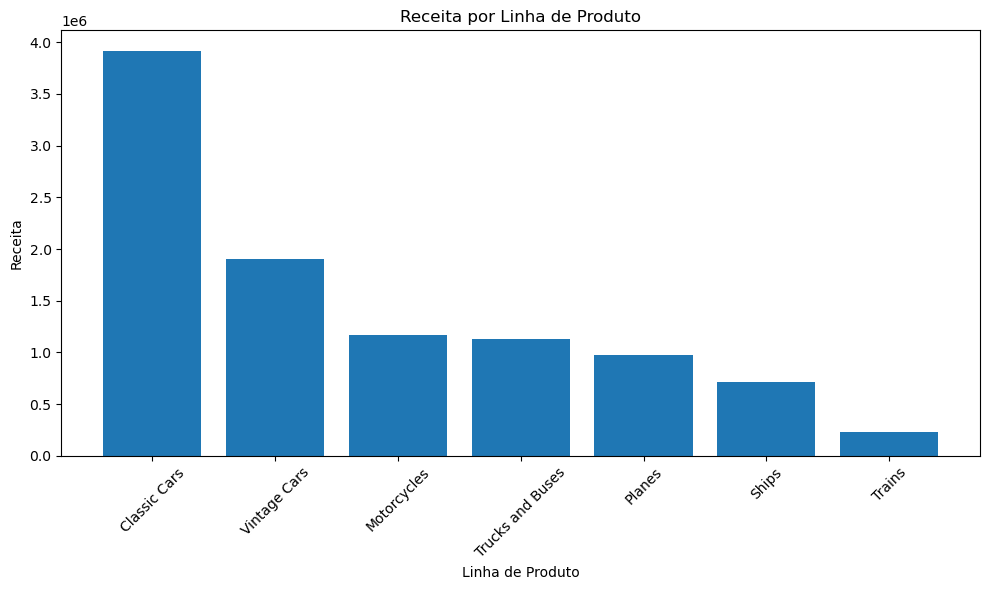

In [17]:
# Receita por linha de produto

plt.figure(figsize=(10,6))
plt.bar(receita_produto["PRODUCTLINE"], receita_produto["SALES"])
plt.xlabel("Linha de Produto")
plt.ylabel("Receita")   
plt.title("Receita por Linha de Produto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

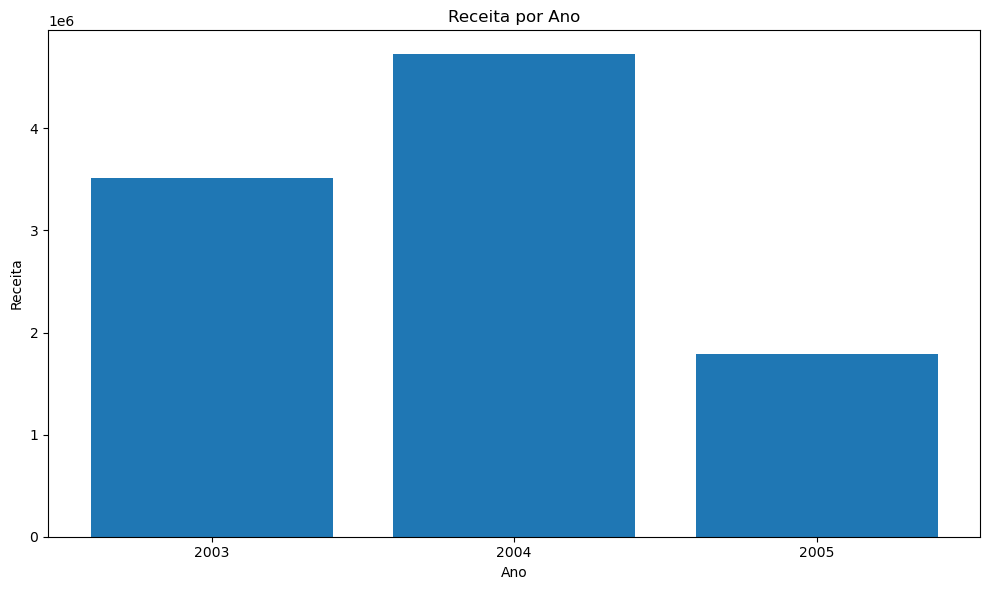

In [18]:
# Receita por Ano

plt.figure(figsize=(10,6))
plt.bar(receita_ano["YEAR_ID"], receita_ano["SALES"])
plt.xlabel("Ano")
plt.ylabel("Receita")
plt.title("Receita por Ano")
plt.xticks(receita_ano["YEAR_ID"])
plt.tight_layout()
plt.show()

### Interpretação Visual

Os gráficos reforçam:
- A concentração geográfica em EMEA
- A dependência das linhas Classic e Vintage
- O crescimento até 2004, com 2005 parcial